# STAT 451: Heart Prediction Project

In [101]:
# import statements
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.mixture import GaussianMixture

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (precision_score, recall_score,
                             accuracy_score, roc_auc_score, f1_score)


In [102]:
# Load dataframe
df = pd.read_csv('heart.csv')

def resumetable(df):
    print(f"data shape: {df.shape}")
    summary = pd.DataFrame(df.dtypes, columns=['data type'])
    summary = summary.reset_index()
    summary = summary.rename(columns = {"index": "feature"})
    summary["Num_Null"] = df.isnull().sum().values
    summary["Num_Unique"] = df.nunique().values
    summary["First_Value"] = df.loc[0].values
    summary["Second_Value"] = df.loc[1].values
    summary["Third_Value"] = df.loc[2].values

    return summary

resumetable(df)

data shape: (918, 12)


,feature,data type,Num_Null,Num_Unique,First_Value,Second_Value,Third_Value
0,Age,int64,0,50,40,49,37
1,Sex,object,0,2,M,F,M
2,ChestPainType,object,0,4,ATA,NAP,ATA
3,RestingBP,int64,0,67,140,160,130
4,Cholesterol,int64,0,222,289,180,283
5,FastingBS,int64,0,2,0,0,0
6,RestingECG,object,0,3,Normal,Normal,ST
7,MaxHR,int64,0,119,172,156,98
8,ExerciseAngina,object,0,2,N,N,N
9,Oldpeak,float64,0,53,0.0,1.0,0.0


### Data Preprocessing

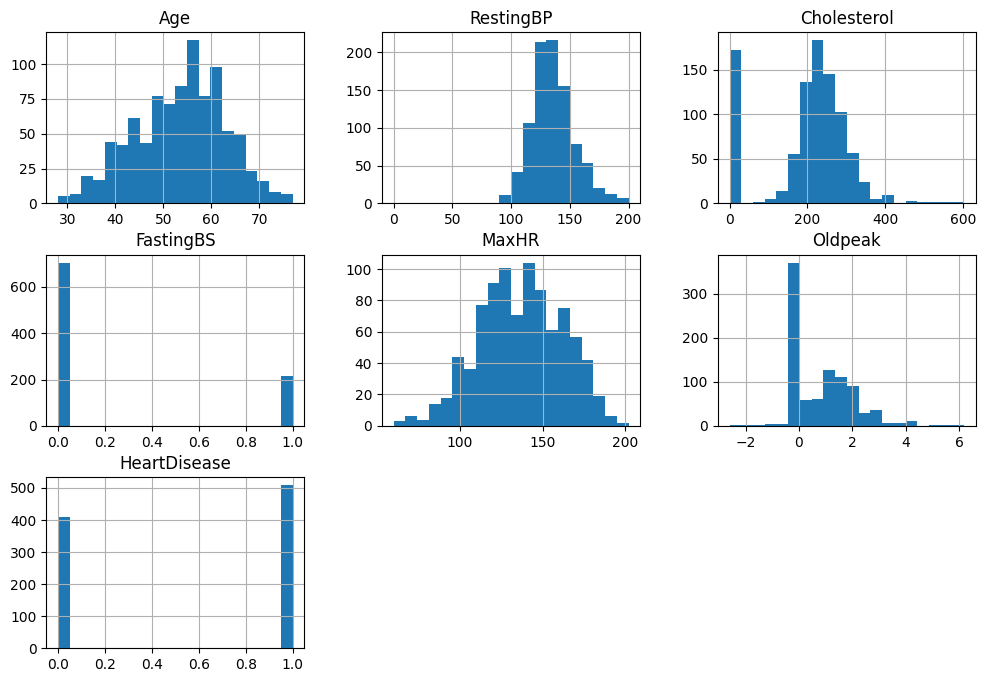

In [103]:
df.describe()

# Check for class imbalance
df['HeartDisease'].value_counts(normalize=True)

# Perform exploratory data analysis to understand variable distributions
df.hist(bins=20, figsize=(12, 8))
plt.show()

# Outlier from raw data: RestingBP = 0 (data imputation with median)
# print(df[df['RestingBP'] == 0].shape[0])
median_bp = df.loc[df['RestingBP'] != 0, 'RestingBP'].median()
df['RestingBP'] = df['RestingBP'].replace(0, median_bp)

In [104]:
# Encode categorical variables
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
df = pd.get_dummies(df, columns=categorical_cols)

X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

# Outlier detection with GMM
clf = GaussianMixture(n_components=1, random_state=0)
clf.fit(X)
pdf_values = np.exp(clf.score_samples(X)) # converts log-likelihoods to probability densities
threshold = np.quantile(pdf_values, 0.02) # set cutoff at the bottom 2% of the distribution
outlier_mask = pdf_values <= threshold # select those samples as outliers
# keep only non-outliers
X = X[~outlier_mask]
y = y[~outlier_mask]

# Scale numerical features
numeric_cols = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

### Feature Selection & Engineering

In [105]:
# Conduct feature selection methods (SelectKBest)
selector = SelectKBest(score_func=f_classif, k=3)
X_new = selector.fit_transform(X=X, y=y)
mask = selector.get_support()  # boolean mask of selected features
selected_features = X.columns[mask]
print(f"Top selected features: {selected_features}")

Top selected features: Index(['ChestPainType_ASY', 'ST_Slope_Flat', 'ST_Slope_Up'], dtype='object')


### Model Development

In [106]:
# Split data into training, validation, and test sets
X_train, X_tmp, y_train, y_tmp = train_test_split(X_new, y, test_size=.2,
                                                  random_state=0, stratify=y)
X_valid, X_test, y_valid, y_test = train_test_split(X_tmp, y_tmp, test_size=.5,
  random_state=0, stratify=y_tmp)

best_index = -1
best_score = -np.Inf
best_clf = None
best_params = None

# make a list of classifiers without setting any hyperparameters
classifiers = [
    LogisticRegression(max_iter=5000),
    RandomForestClassifier(criterion='entropy'),
    SVC(probability=True)
]

# make a list of parameter dictionaries
parameters = [
    {'C': [0.01, 1, 100]}, # Logistic Regression
    {'n_estimators': [50, 100, 200], 'max_depth':  [None, 5, 10]}, # Random Forest
    {'kernel': ('linear', 'rbf'), 'C': [0.01, 1, 100]} # SVC
]

clf_names = ['Logistic Regression', 'Random Forest', 'SVC']

for i in range(len(classifiers)):
    print(f'Training {clf_names[i]}...')
    grid_search = GridSearchCV(classifiers[i], parameters[i])
    grid_search.fit(X_train, y_train)
    clf = grid_search.best_estimator_
    valid_score = clf.score(X_valid, y_valid)
    print(f'Validation accuracy={valid_score:.3}, ' +
          f'clf.best_score_={grid_search.best_score_:.3}, ' +
          f'clf.best_params_={grid_search.best_params_}')
    
    if valid_score > best_score:
        best_score = valid_score
        best_index = i
        best_clf = clf
        best_params = grid_search.best_params_

print('__________________________________________')
print(f'Best classifier: {clf_names[best_index]}')
print(f'Parameters: {best_params}')
print(f'Validation accuracy: {best_score:.3}')

Training Logistic Regression...
Validation accuracy=0.856, clf.best_score_=0.822, clf.best_params_={'C': 0.01}
Training Random Forest...
Validation accuracy=0.856, clf.best_score_=0.822, clf.best_params_={'max_depth': 10, 'n_estimators': 200}
Training SVC...
Validation accuracy=0.856, clf.best_score_=0.822, clf.best_params_={'C': 0.01, 'kernel': 'linear'}
__________________________________________
Best classifier: Logistic Regression
Parameters: {'C': 0.01}
Validation accuracy: 0.856


### Model Evaluation

In [107]:
y_pred = best_clf.predict(X_test)
y_pred_proba = best_clf.predict_proba(X_test)[:,1]

print(f'Test accuracy: {best_clf.score(X_test, y_test):.3}')
print(f'Precision: {precision_score(y_test, y_pred):.3}')
# Means model is correctly identifying ~80% of patients who actually have heart disease
print(f'Recall: {recall_score(y_test, y_pred):.3}') # more important 
print(f'F1-score: {f1_score(y_test, y_pred):.3}')
print(f'AUC: {roc_auc_score(y_test, y_pred_proba):.3}')

Test accuracy: 0.756
Precision: 0.765
Recall: 0.796
F1-score: 0.78
AUC: 0.838
